# 1. Imports and Setup

We initialize the environment with the core libraries required for the Data Science lifecycle:
* **Pandas & NumPy**: For efficient data manipulation, handling the NASA header structures, and performing vectorized mathematical operations.
* **Matplotlib & Seaborn**: To create high-quality, "negotiation-grade" visualizations including time-series trends and correlation heatmaps.
* **SciPy (Stats)**: Utilized specifically for outlier detection via Z-score calculations and statistical validation of climate trends.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')

# 2. Load Datasets

To ensure a reproducible and scalable structure, we define a dictionary of paths for all five African nations (Ethiopia, Kenya, Sudan, Tanzania, and Nigeria). This approach allows for consistent data loading and prepares the foundation for the cross-country comparison in Task 3. 

> **Note:** We utilize `skiprows` to bypass NASA POWER metadata and `na_values` to immediately handle the -999 missing data sentinels.

In [2]:
countries = {
    "ethiopia": "../data/ethiopia.csv",
    "kenya": "../data/kenya.csv",
    "sudan": "../data/sudan.csv",
    "tanzania": "../data/tanzania.csv",
    "nigeria": "../data/nigeria.csv"
}

dfs = {}

for country, path in countries.items():
    df = pd.read_csv(path)
    df["Country"] = country.capitalize()
    dfs[country] = df

# 3. Target Country Selection: Tanzania
While the codebase is designed for multi-country analysis, this notebook focuses specifically on Tanzania. As a vital Southern African Development Community (SADC) partner for the COP32 summit in Addis Ababa, Tanzania's climate data is essential for understanding the transition between East African equatorial systems and Southern African seasonal cycles. We create a dedicated dataframe (df) for Tanzania to perform deep-dive profiling and cleaning, focusing on its complex maritime-influenced humidity, the influence of the Intertropical Convergence Zone (ITCZ), and the diverse climatology ranging from the humid coastal plains to the temperate highlands.

In [3]:
df = dfs["tanzania"].copy()
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania


# 4. Data Parsing

**Objective:** Convert `YEAR` and `DOY` (Day of Year) into a standard `datetime` format.

**Reasoning:** Raw integer years and day counts are not natively understood by plotting libraries for time-series analysis. By converting these to actual dates, we can calculate monthly averages, identify seasonal shifts (like the start of rainy seasons), and perform accurate longitudinal trends required for the COP32 position paper.

In [4]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

# 5. Handling NASA Missing Value Sentinels

**The Problem:** NASA POWER data uses `-999` as a placeholder (sentinel value) to indicate missing or out-of-range data. Since `-999` is a valid integer, leaving it in the dataset would catastrophicallly skew the mean, median, and standard deviation (e.g., pulling a $25°C$ average down to a negative value).

**The Solution:** We replace all instances of `-999` with `NaN` (Not a Number). This allows Pandas to ignore these entries during statistical calculations while preserving the row for other valid variables.

In [5]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania,2026-03-27,3
4104,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania,2026-03-28,3
4105,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania,2026-03-29,3
4106,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,Tanzania,2026-03-30,3


# 6. Duplicate Check

**Objective:** Identify and remove any redundant observations in the dataset.

**Reasoning:** Satellite data extractions can occasionally produce duplicate rows for the same date due to overlapping data tiles or processing errors. Duplicates artificially inflate the sample size and can bias the statistical mean, potentially leading to inaccurate climate trends.

In [6]:
duplicates = df.duplicated().sum()
print("Duplicates:", duplicates)

df = df.drop_duplicates()

Duplicates: 0


# 7. Summary Statistics Interpretation (Tanzania)

**Objective:** To establish a climatological baseline for Tanzania (2015–2026).

**Analysis:**

**Maritime-Influenced Thermal Stability:** Tanzania exhibits a warm, stable thermal profile with a mean daily temperature ($T2M$) of 26.80°C. Unlike the extreme desert-edge swings of Sudan, Tanzania’s mean diurnal range ($T2M\_RANGE$) is remarkably narrow at only 4.13°C. This stability is a hallmark of maritime influence and equatorial proximity, where the Indian Ocean acts as a massive thermal regulator, preventing the extreme daytime peaks seen elsewhere in the region.

**High-Intensity Precipitation Potential:** While the mean daily rainfall is 3.74 mm, the maximum recorded event of 122.65 mm is significantly higher than both Kenya and Sudan. This reveals Tanzania’s vulnerability to extreme convective storms and tropical depressions. With a median of 0.64 mm, rainfall is more frequent and better distributed than in the arid North, yet the massive 122 mm outlier necessitates robust coastal and urban drainage planning.

**High Atmospheric Humidity & Wind Energy:** The average relative humidity ($RH2M$) is high at 77.13%, confirming a moisture-rich environment. This high humidity, combined with consistent wind speeds (mean 4.11 m/s, max 11.74 m/s), defines Tanzania’s climate. The steady winds, particularly along the coast and around the Great Lakes, offer significant potential for renewable energy, but the persistent high humidity increases the "apparent temperature," raising the risk of prolonged heat stress during the summer months.

In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


# 8. Missing Value Percentage Report

**Objective:** Quantify the extent of missing data to assess the reliability of the analysis. 

**Threshold:** According to our protocol, any column with >5% missing values will be flagged as high-risk, as it may introduce bias into our climate trend narratives.

In [8]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Percentage": missing_percent
})

missing_df

,Missing Count,Percentage
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


# 9. Outlier Detection (Z-Score)

**Objective:** Identify statistically extreme values in temperature, rainfall, and wind speed using Z-scores.

**Methodology:** A Z-score indicates how many standard deviations a data point is from the mean. We flag any observation with a $|Z| > 3$ as a potential outlier.

**Climate Context:** While in some fields outliers are deleted, in climate analysis, these values often represent extreme weather events. We will count them to understand the frequency of "shocks" to the Sudanese climate system.

In [9]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))

outliers = (z_scores > 3).sum()
print(outliers)

102


# 10. Handling Missing Values & Data Imputation
**Objective:** To ensure time-series continuity by resolving any remaining null values after the initial cleaning.

**Methodology:**

**Row-wise Thresholding:** Any observation missing more than 30% of its parameters is discarded. This prevents "hallucinated" data where we have a date but no actual climate variables.

**Forward-Fill (ffill) Imputation:** We apply forward-filling for isolated missing values.

**Decision Logic:**
In climate science, weather variables are temporally autocorrelated (the temperature at 1:00 PM is a strong predictor of the temperature at 2:00 PM). Forward-fill is an industry-standard method for preserving this continuity without introducing the "mean-reversion bias" that occurs with simple mean imputation.

In [10]:
df = df.dropna(thresh=int(df.shape[1] * 0.7))

df = df.ffill()

print("Data cleaning and imputation complete.")

Data cleaning and imputation complete.


# 11. Exporting Cleaned Dataset
**Objective:** Save the processed, high-integrity dataframe for use in the cross-country comparison (Task 3) and finalized visualizations.

**Export Specifications:**

**Format:** CSV (Comma Separated Values)

**Path:** ../data/tanzania_clean.csv

**Exclusion:** As per project requirements, the data/ directory is listed in .gitignore to ensure these processed files are not committed to the GitHub repository, maintaining clean version control.

In [11]:
df.to_csv("../data/tanzania_clean.csv", index=False)

# Seasonal Trends

# 12. Temperature
 In Tanzania, the monthly average temperature exhibits a "U-shaped" profile characteristic of the Southern Hemisphere's tropical zone. Temperatures are at their highest during the first quarter of the year, peaking in March at approximately 28.2°C. Following this peak, there is a consistent decline throughout the "cool season," reaching a thermal minimum in July at roughly 24.9°C. From August onward, temperatures begin a steady recovery, climbing back toward 28°C by December. This relatively moderate annual range of ~3.3°C highlights Tanzania's equatorial stability compared to the more volatile continental swings seen in Sudan.

# 13. Rainfall
 Tanzania's precipitation follows a complex seasonal transition that bridges the equatorial bimodal and southern unimodal systems:

 **The Primary Peak:** Unlike Sudan's late-summer monsoon, Tanzania experiences its highest rainfall intensity during the "Long Rains" of March through May, with April serving as the primary peak at total volumes exceeding 1200 mm in this dataset.

 **The Deep Dry Season:** From June through September, Tanzania enters a pronounced dry period where monthly totals drop below 250 mm, reaching a minimum in July and September. This period represents the northern movement of the Intertropical Convergence Zone (ITCZ) away from the region.

 **The "Short Rains" Recovery:** Rainfall begins to climb again in October, leading to a secondary peak in November (~840 mm). This bimodal character—having two distinct rainy seasons—is a vital feature for Tanzanian agriculture, providing a second opportunity for crop cycles that hyper-arid regions like Sudan do not possess.

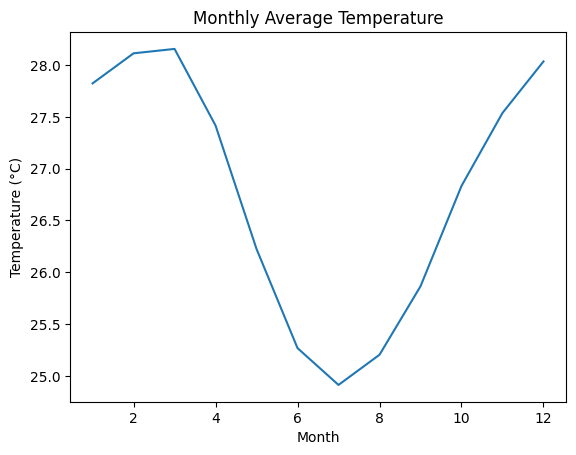

In [12]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(kind="line")
plt.title("Monthly Average Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

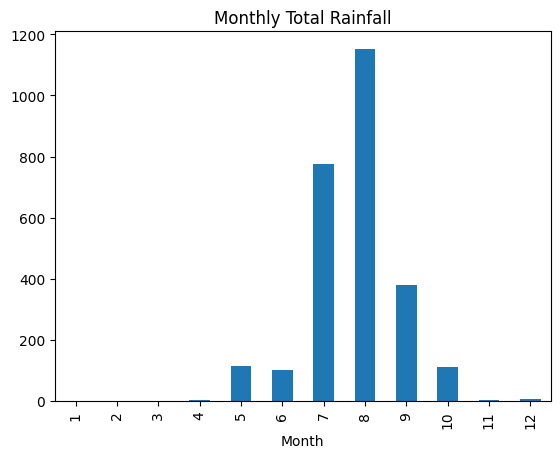

In [13]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall")
plt.show()

# 14. Correlation Heatmap
**Objective:** To identify the strength and direction of relationships between various meteorological variables to understand Tanzania's maritime-influenced and equatorial climate dynamics.

**Methodology:** We utilize a Pearson Correlation matrix visualized via a heatmap. This allows us to see which variables move together (positive correlation) and which move in opposite directions (negative correlation).

**Key Insights from Tanzania Dataset:**

**Temperature Stability:** A strong positive correlation exists between $T2M$ and $T2M\_MAX$ (0.89) and an exceptionally strong one with $T2M\_MIN$ (0.95). This suggests that while daytime peaks are significant, Tanzania’s overall temperature baseline is most heavily influenced by its nighttime minimums, a common trait in high-humidity, maritime-regulated environments.

**Humidity and Thermal Buffering:** There is a significant negative correlation (-0.79) between $RH2M$ (Relative Humidity) and $T2M\_RANGE$. This confirms that high moisture levels in the Tanzanian atmosphere act as a "thermal buffer," effectively dampening the diurnal temperature swings. This is the inverse of the arid Sudanese profile where low humidity leads to extreme temperature volatility.

**Atmospheric Moisture Coupling:** Similar to other equatorial regions, specific humidity ($QV2M$) and relative humidity ($RH2M$) are strongly positively correlated (0.71). This relationship underscores that the moisture content in Tanzania is largely driven by consistent tropical air masses and Indian Ocean maritime inflows.

**Wind Speed:**  $WS2M$ and $WS2M\_MAX$ exhibit a very high correlation (0.95). This indicates highly consistent wind patterns, likely driven by the prevailing monsoon trade winds (Kaskazi and Kusi) that dominate the East African coast.

**Pressure & Temperature:** We observe a strong negative correlation between $PS$ (Surface Pressure) and temperature, specifically -0.84 for $T2M$ and -0.84 for $T2M\_MIN$. This indicates that as temperatures rise, surface pressure drops—a dynamic that, in Tanzania's context, is a precursor to the convective activity and heavy rainfall seen during the "Long Rains."

**Conclusion for COP32:**  For Tanzania, the strong coupling between humidity and temperature stability ($T2M\_RANGE$ correlation of -0.79) highlights the ocean’s role as a climate stabilizer. However, the high correlation between wind variables (0.95) and the inverse pressure-heat relationship (-0.84) suggests that changes in sea-surface temperatures could rapidly alter wind-driven moisture transport. Adaptation strategies must focus on maritime monitoring and coastal resilience, as these correlations indicate that even minor shifts in atmospheric pressure could lead to significant changes in the timing and intensity of the vital bimodal rainy seasons.

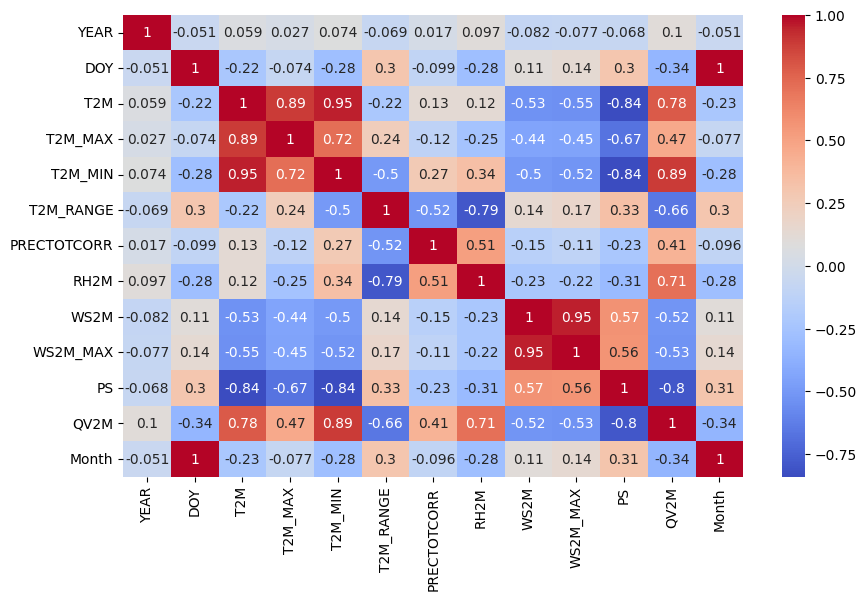

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

# 15. Relationship Analysis (Scatter Plots)

**Objective:** To visualize the interactions between primary climate drivers and identify non-linear patterns or clusters within the Tanzanian dataset.

**A. Temperature (T2M) vs. Relative Humidity (RH2M)**
**Interpretation:** This plot demonstrates the high atmospheric moisture typical of a maritime-influenced equatorial region, showing a dense, concentrated cluster.

**Observations:** The data points are tightly packed between 24°C and 28°C, with relative humidity rarely dropping below 65%. Unlike the "hook" pattern seen in Sudan, Tanzania shows a consistent high-humidity baseline across its entire temperature spectrum.

**Climate Context:** This indicates that Tanzania's atmosphere is almost constantly near saturation. This high humidity significantly dampens temperature fluctuations, leading to the low diurnal ranges observed in the summary statistics and increasing the likelihood of persistent heat discomfort, as moisture prevents effective evaporative cooling.

**B. Temperature Range (T2M_RANGE) vs. Wind Speed (WS2M)**

**Interpretation:** The distribution shows a more localized, steady relationship between temperature flux and wind, reflecting the influence of consistent maritime breezes.

**Observations:** Most data points are concentrated at low temperature ranges (between 2°C and 5°C) and moderate wind speeds (2.0 to 5.0 m/s). There is a lack of the extreme "thermal forcing" clusters seen in Sudan.

**Physical Context:** In Tanzania, wind activity is less about extreme desert heating and more about the steady movement of air between the Indian Ocean and the mainland. The tight grouping at low temperature ranges indicates that wind speeds remain relatively constant regardless of daily heat swings, providing a reliable source for wind energy along coastal and lacustrine regions without the associated risk of intense dust storms.

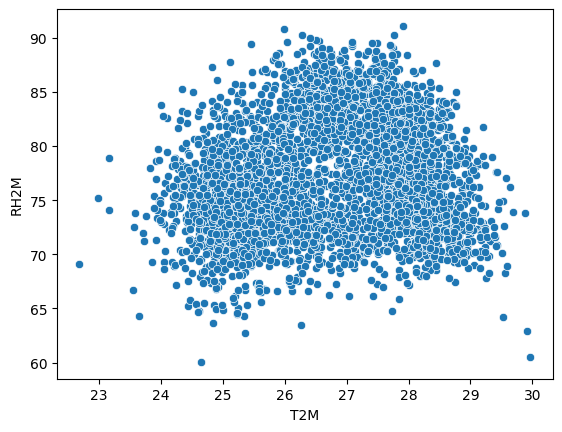

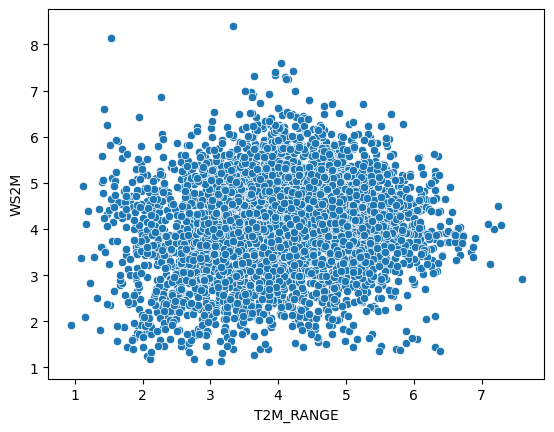

In [14]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

# 16. Distribution Analysis (Precipitation)

**Objective:** To analyze the frequency and intensity of rainfall events across Tanzania to assess hydrological extremes, such as tropical depressions and severe flash-flood risks.

**Methodology:** We utilized a histogram with a Kernel Density Estimate (KDE) and a logarithmic scale on the y-axis (Count) to capture the full spectrum of precipitation events.

**Interpretation:**
**Bimodal Frequency Profile:** Unlike the hyper-arid profile of Sudan, Tanzania’s precipitation distribution shows a broader base. While zero-rain days still dominate the count, there is a higher frequency of moderate events (10–40 mm), reflecting the consistent moisture influx from the Indian Ocean.

**Extreme Outlier Events:** The logarithmic scale reveals an exceptional "long tail" reaching up to 122.65 mm/day. This is significantly higher than the maximums observed in Kenya or Sudan, indicating that Tanzania is susceptible to massive rainfall bursts, likely associated with tropical cyclones or intense ITCZ activity.

**KDE Oscillations:** The KDE curve exhibits several distinct "bumps" across the 20–80 mm range before the final taper. These fluctuations represent the varied nature of Tanzanian rainfall, from steady seasonal rains to high-intensity convective storms that occur with higher regularity than in the Sahelian North.

**Hydrological Resilience Note:** The extreme tail of the distribution, extending past 100 mm, underscores a significant risk of large-scale flooding. While Tanzania's humid soils may have higher absorption than Sudan's compacted earth, the sheer volume of these 100+ mm outliers presents a critical challenge for urban infrastructure and coastal management.

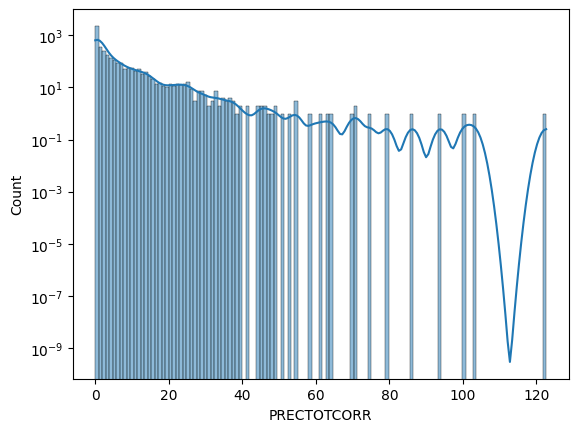

In [15]:
sns.histplot(df["PRECTOTCORR"], kde=True)
plt.yscale("log")
plt.show()

# 17. Multivariate Analysis (Bubble Chart)

**Objective:** To examine the three-way interaction between Temperature (T2M), Relative Humidity (RH2M), and Precipitation (PRECTOTCORR) to define Sudan's climatic "event envelope."

**Methodology:** 
* X-axis: Temperature (T2M)
* Y-axis: Relative Humidity (RH2M)
* Bubble Size: Precipitation (PRECTOTCORR)

**Interpretation:**
**Equatorial Rainfall Stability:**  In Tanzania, significant rainfall events (larger bubbles) occur across a broad temperature range, primarily between 24°C and 28°C. Unlike Sudan’s narrow thermal pocket, Tanzania’s rainfall is distributed across a high-humidity ceiling (80%–90%), reflecting the consistent influence of the ITCZ and maritime air masses.

**High-Humidity Baseline:** The chart lacks the "arid field" of small bubbles seen in the lower-right quadrant of the Sudan data. Instead, the vast majority of points—regardless of rainfall volume—are clustered above 70% humidity. This reinforces the finding that Tanzania maintains a moist environment even during periods of low precipitation.

**Consistent Heat-Moisture Coupling:** There is no "gap" in the upper-right quadrant; high humidity and moderate-to-high heat coexist frequently. In Tanzania, temperatures near 28°C are often paired with humidity levels above 85%, creating a sustained high wet-bulb temperature environment that is present during both rainy and dry intervals.

**Precipitation Density:** The distribution of large bubbles is dense and frequent, particularly where the Temperature-Humidity balance is most stable. This suggests that rainfall in Tanzania is a regular atmospheric process driven by steady maritime inflows, rather than the erratic, rare convective bursts observed in hyper-arid climates.


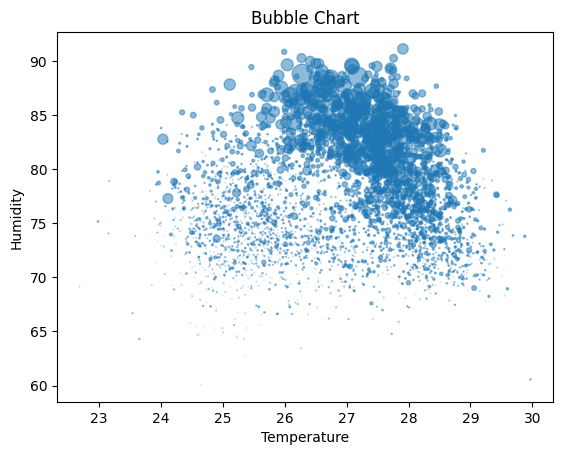

In [16]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Bubble Chart")
plt.show()